# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "ch3br"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[7.73 7.67 7.61 ... 9.58 9.28 9.28] [7.73 7.67 7.815454545454546 ... 11.605 9.28 9.28] [7.73 7.772727272727273 8.41 ... 11.605 9.28 9.28] [7.73 8.277272727272727 8.824545454545454 ... 11.605 9.28 9.28] [7.73 7.67 7.913636363636364 ... 11.059393939393939 9.28 9.28] [7.73 7.67 7.61 ... 9.968181818181817 9.28 9.28]] [[7.6 7.668333333333333 7.736666666666666 ... 10.0825 9.911249999999999 9.74] [7.6 7.668333333333333 7.761818181818182 ... 10.558333333333334 10.149166666666666 9.74] [7.6 7.680909090909091 7.977678571428571 ... 9.25625 9.773541666666667 9.74] [7.6 7.924772727272726 8.249545454545453 ... 9.807083333333333 9.91125 9.74] [7.6 7.668333333333333 7.864886363636364 ... 10.0825 9.91125 9.74] [7.6 7.668333333333333 7.736666666666666 ... 10.082500000000001 9.911249999999999 9.74]] [[7.75 7.7700000000000005 7.79 ... 11.4 12.115 10.7] [7.75 7.77 7.8118181818181816 ... 11.246666666666666 10.973333333333333 10.7] [7.749999999999999 7.780909090909091 8.082142857142857 ... 9.977500000000001 10.536111111111111 10.7] [7.75 8.098181818181818 8.446363636363635 ... 10.372222222222222 10.930833333333332 10.7] [7.749999999999999 7.77 7.954090909090909 ... 10.766944444444444 11.325555555555555 10.7] [7.75 7.7700000000000005 7.789999999999999 ... 11.161666666666667 11.720277777777778 10.7]] ... [[5.99 6.046666666666667 6.1033333333333335 ... 6.768333333333333 6.726666666666667 6.4375] [5.99 6.046666666666667 6.122727272727273 ... 7.01 6.72375 6.4375] [5.99 6.056363636363637 6.176875 ... 6.705 6.588518518518518 6.4375] [5.99 6.066190476190476 6.142380952380952 ... 6.68962962962963 6.623055555555556 6.4375] [5.99 6.046666666666667 6.113095238095238 ... 6.67425925925926 6.657592592592593 6.4375] [5.99 6.046666666666667 6.1033333333333335 ... 6.658888888888889 6.69212962962963 6.4375]] [[6.0 5.989166666666668 5.9783333333333335 ... 6.29625 6.305 6.35] [6.0 5.989166666666667 6.090456140350877 ... 6.793333333333334 6.571666666666667 6.35] [6.0 6.045228070175439 6.258640350877194 ... 6.86 6.571666666666666 6.35] [6.0 6.080357142857143 6.160714285714286 ... 6.703611111111112 6.505000000000001 6.35] [6.0 5.989166666666667 6.023928571428572 ... 6.5472222222222225 6.4383333333333335 6.35] [6.0 5.989166666666667 5.9783333333333335 ... 6.390833333333333 6.371666666666667 6.35]] [[6.0 6.0200000000000005 6.040000000000001 ... 6.577999999999999 6.276 6.236] [6.0 6.02 6.132061403508772 ... 6.23 6.2330000000000005 6.236] [6.0 6.066030701754386 6.27015350877193 ... 6.875 6.524444444444444 6.236] [6.0 6.086190476190476 6.172380952380952 ... 6.711703703703704 6.4623333333333335 6.236] [6.0 6.02 6.073095238095237 ... 6.5484074074074075 6.400222222222222 6.236] [6.0 6.02 6.039999999999999 ... 6.385111111111111 6.338111111111111 6.236]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[7.73 7.67 7.61 ... 9.58 9.28 9.28] [7.73 7.67 7.815454545454546 ... 11.605 9.28 9.28] [7.73 7.772727272727273 8.41 ... 11.605 9.28 9.28] [7.73 8.277272727272727 8.824545454545454 ... 11.605 9.28 9.28] [7.73 7.67 7.913636363636364 ... 11.059393939393939 9.28 9.28] [7.73 7.67 7.61 ... 9.968181818181817 9.28 9.28]] [[7.6 7.668333333333333 7.736666666666666 ... 10.0825 9.911249999999999 9.74] [7.6 7.668333333333333 7.761818181818182 ... 10.558333333333334 10.149166666666666 9.74] [7.6 7.680909090909091 7.977678571428571 ... 9.25625 9.773541666666667 9.74] [7.6 7.924772727272726 8.249545454545453 ... 9.807083333333333 9.91125 9.74] [7.6 7.668333333333333 7.864886363636364 ... 10.0825 9.91125 9.74] [7.6 7.668333333333333 7.736666666666666 ... 10.082500000000001 9.911249999999999 9.74]] [[7.75 7.7700000000000005 7.79 ... 11.4 12.115 10.7] [7.75 7.77 7.8118181818181816 ... 11.246666666666666 10.973333333333333 10.7] [7.749999999999999 7.780909090909091 8.082142857142857 ... 9.977500000000001 10.536111111111111 10.7] [7.75 8.098181818181818 8.446363636363635 ... 10.372222222222222 10.930833333333332 10.7] [7.749999999999999 7.77 7.954090909090909 ... 10.766944444444444 11.325555555555555 10.7] [7.75 7.7700000000000005 7.789999999999999 ... 11.161666666666667 11.720277777777778 10.7]] ... [[5.99 6.046666666666667 6.1033333333333335 ... 6.768333333333333 6.726666666666667 6.4375] [5.99 6.046666666666667 6.122727272727273 ... 7.01 6.72375 6.4375] [5.99 6.056363636363637 6.176875 ... 6.705 6.588518518518518 6.4375] [5.99 6.066190476190476 6.142380952380952 ... 6.68962962962963 6.623055555555556 6.4375] [5.99 6.046666666666667 6.113095238095238 ... 6.67425925925926 6.657592592592593 6.4375] [5.99 6.046666666666667 6.1033333333333335 ... 6.658888888888889 6.69212962962963 6.4375]] [[6.0 5.989166666666668 5.9783333333333335 ... 6.29625 6.305 6.35] [6.0 5.989166666666667 6.090456140350877 ... 6.793333333333334 6.571666666666667 6.35] [6.0 6.045228070175439 6.258640350877194 ... 6.86 6.571666666666666 6.35] [6.0 6.080357142857143 6.160714285714286 ... 6.703611111111112 6.505000000000001 6.35] [6.0 5.989166666666667 6.023928571428572 ... 6.5472222222222225 6.4383333333333335 6.35] [6.0 5.989166666666667 5.9783333333333335 ... 6.390833333333333 6.371666666666667 6.35]] [[6.0 6.0200000000000005 6.040000000000001 ... 6.577999999999999 6.276 6.236] [6.0 6.02 6.132061403508772 ... 6.23 6.2330000000000005 6.236] [6.0 6.066030701754386 6.27015350877193 ... 6.875 6.524444444444444 6.236] [6.0 6.086190476190476 6.172380952380952 ... 6.711703703703704 6.4623333333333335 6.236] [6.0 6.02 6.073095238095237 ... 6.5484074074074075 6.400222222222222 6.236] [6.0 6.02 6.039999999999999 ... 6.385111111111111 6.338111111111111 6.236]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'ch3br' (lon: 6, lat: 12, year: 26, month: 12)> Size: 180kB
<Quantity([[[[ 7.83        7.58        8.055      ...  8.03        8.155
     7.55      ]
   [ 7.705       7.65        7.81       ...  7.51        7.66
     7.5       ]
   [ 7.45        7.72        7.54       ...  7.43        7.31666667
     7.46      ]
   ...
   [ 6.025       6.22666667  6.34       ...  5.93666667  6.09333333
     5.93333333]
   [ 5.9275      5.9975      5.92       ...  5.83333333  5.76666667
     5.75      ]
   [ 5.81        5.72        5.84       ...  5.87        5.82666667
     6.035     ]]

  [[ 7.83        7.8995      8.055      ...  8.17645     8.155
     7.83735   ]
   [ 7.705       7.72445     7.68868333 ...  7.69043333  7.67476667
     7.416     ]
   [ 7.45        7.594       7.54       ...  7.2773      7.34053333
     7.37426667]
...
   [ 6.58833333  6.84025     7.05808333 ...  6.57516667  6.63025
     6.66341667]
   [ 6.68266667  6.71916667  6.96091667 ...  6.19891667  6.27783333
     6.32133333]
   [ 6.43258333  6.55866667  6.64941667 ...  6.5695      6.44066667
     6.46425   ]]

  [[10.9325     10.83333333 10.98666667 ...  9.98       10.39
    10.495     ]
   [10.51       10.465      10.62       ...  8.93        9.72
     9.59      ]
   [ 9.74666667  9.79        9.94       ...  8.56666667  9.17
     9.365     ]
   ...
   [ 6.65433333  6.8165      7.02366667 ...  6.52775     6.38775
     6.5015    ]
   [ 6.58525     6.56875     6.7205     ...  6.12825     6.2265
     6.33      ]
   [ 6.3235      6.44825     6.76766667 ...  6.41116667  6.431
     6.48275   ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[7.83 7.58 8.055 ... 5.87 5.826666666666667 6.035] [7.83 7.899500000000001 8.055 ... 5.760000000000001 5.796733333333333 5.935683333333333] [7.97 7.932499999999999 8.1855 ... 5.74 5.817 5.943416666666667] ... [10.904444444444444 10.892222222222223 10.982499999999998 ... 6.683166666666667 6.6584166666666675 6.64475] [10.9325 10.833333333333334 10.986666666666666 ... 6.552 6.4350000000000005 6.470000000000001] [10.9325 10.833333333333334 10.986666666666666 ... 6.43225 6.439500000000001 6.522625000000001]] [[7.83 7.58 8.055 ... 5.87 5.826666666666667 6.035] [7.83 7.995 8.055 ... 5.73 5.779999999999999 5.9] [8.430714285714286 8.332857142857144 8.502857142857142 ... 5.907321428571429 5.913035714285713 6.007916666666667] ... [10.67 10.54 11.088333333333333 ... 6.86 6.62 6.585] [10.9325 10.833333333333334 10.986666666666666 ... 6.656666666666666 6.534000000000001 6.57375] [10.9325 10.833333333333334 10.986666666666666 ... 6.453333333333333 6.448 6.5625]] [[7.83 7.579999999999999 8.055 ... 5.87 5.826666666666667 6.035] [7.83 7.956428571428572 8.055 ... 5.883705882352942 5.865049019607842 6.025454545454545] [8.200357142857143 8.294285714285714 8.344178571428571 ... 6.051117647058823 5.988480392156863 6.141363636363637] ... [10.641029411764706 10.513235294117646 11.088333333333331 ... 7.223 6.8525 6.85] [10.9325 10.833333333333334 10.986666666666666 ... 6.720000000000001 6.615 6.65] [10.9325 10.833333333333334 10.986666666666666 ... 6.4111666666666665 6.431 6.482749999999999]] [[7.83 7.58 8.055 ... 5.87 5.826666666666667 6.035] [7.83 7.850833333333333 8.055 ... 6.0031875 5.934083333333334 6.1306875000000005] [7.969999999999999 8.121666666666666 8.1855 ... 6.136375 6.0415 6.226375] ... [10.612058823529411 10.486470588235294 11.088333333333331 ... 6.84 6.49 6.5024999999999995] [10.9325 10.833333333333334 10.986666666666666 ... 6.6045 6.452 6.45275] [10.9325 10.833333333333334 10.986666666666666 ... 6.369 6.414 6.403]] [[7.83 7.579999999999999 8.055 ... 5.87 5.826666666666667 6.035] [7.83 7.7085 8.055 ... 5.82 5.8302000000000005 6.00705] [7.97 7.860416666666666 8.1855 ... 5.8765937500000005 5.894041666666666 6.058760416666667] ... [10.583088235294117 10.45970588235294 10.985838383838384 ... 6.7877222222222215 6.546138888888889 6.5499166666666655] [10.9325 10.833333333333334 10.986666666666666 ... 6.587 6.4463333333333335 6.4585] [10.9325 10.833333333333334 10.986666666666666 ... 6.390083333333333 6.422499999999999 6.442875]] [[7.83 7.58 8.055 ... 5.87 5.826666666666667 6.035] [7.83 7.804000000000001 8.055 ... 5.79 5.813466666666667 5.971366666666667] [7.97 7.837 8.1855 ... 5.77 5.833733333333333 5.9791] ... [10.554117647058822 10.432941176470587 10.780848484848484 ... 6.735444444444444 6.602277777777778 6.597333333333333] [10.9325 10.833333333333334 10.986666666666666 ... 6.5695 6.440666666666667 6.46425] [10.9325 10.833333333333334 10.986666666666666 ... 6.4111666666666665 6.431 6.482749999999999]]]
Units,ppt


### Longitudinal-mean

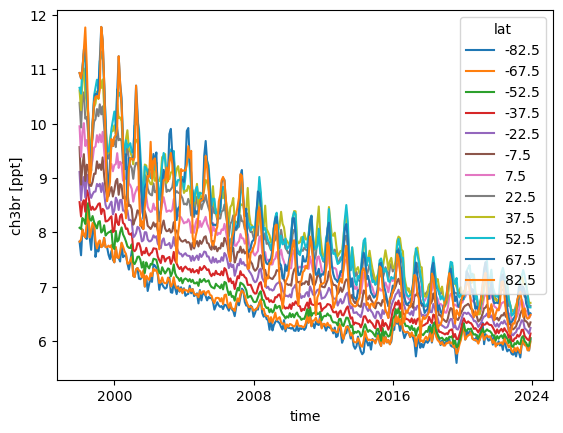

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

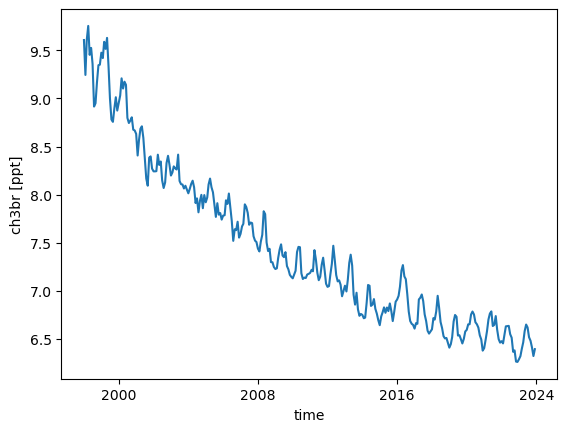

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

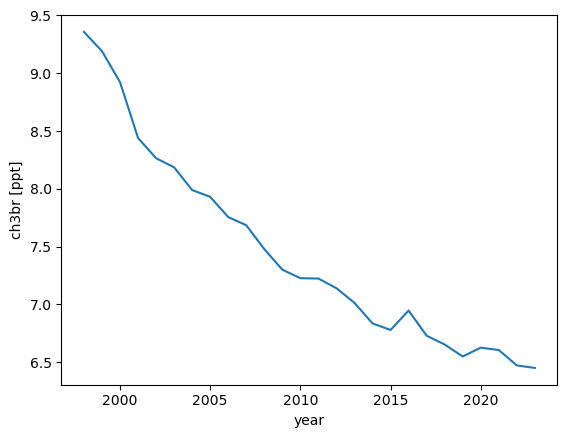

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 26)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 208B 1998 1999 2000 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4598 0.138 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -3.287 0.662 ... 3.865e-16

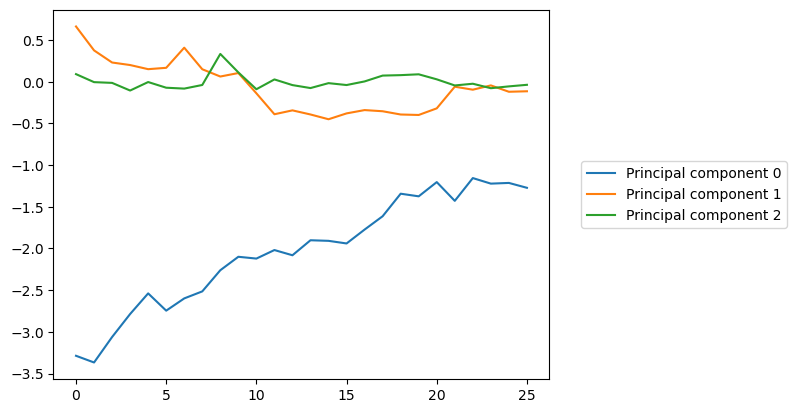

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

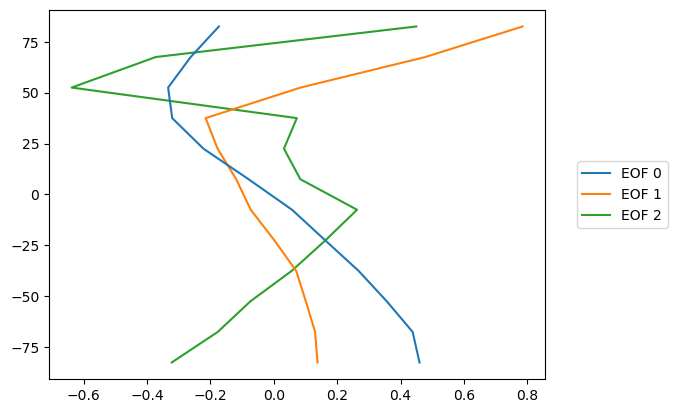

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

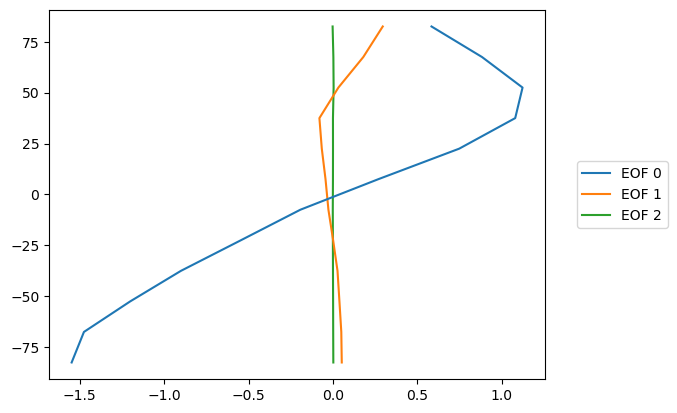

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4597866051964317] [0.4381580270426008] [0.35675784022321416] [0.2675245316882312] [0.1622341362410578] [0.05757096546662261] [-0.07958251948429915] [-0.2219859296677939] [-0.32045766309558177] [-0.33337782147444367] [-0.2620739440945149] [-0.17322294922662262]]
Units,ppt
Magnitude,[[-3.2871812846220743] [-3.3674029386442244] [-3.0621132888866724] [-2.7860954828020894] [-2.5388223051919865] [-2.7459505535401814] [-2.5990922860335437] [-2.5149119373225215] [-2.2610896047478946] [-2.099844632294997] [-2.1213826263673217] [-2.0191123951817893] [-2.081599951408842] [-1.901661965756753] [-1.9086619572773074] [-1.940104377848825] [-1.773600101956477] [-1.613696036689696] [-1.3434920700034936] [-1.374831205341948] [-1.2042707490743194] [-1.429136734927102] [-1.155975455964302] [-1.2225697932263766] [-1.214191428153467] [-1.2726890154552457]]
Units,dimensionless


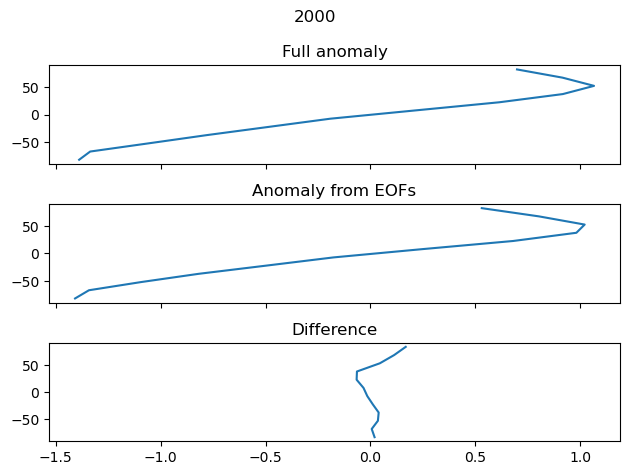

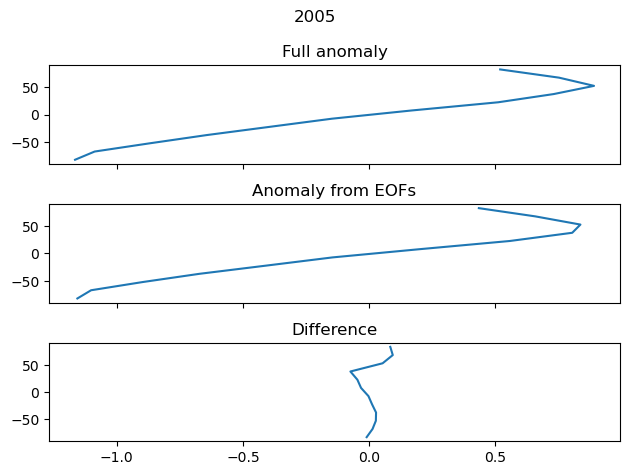

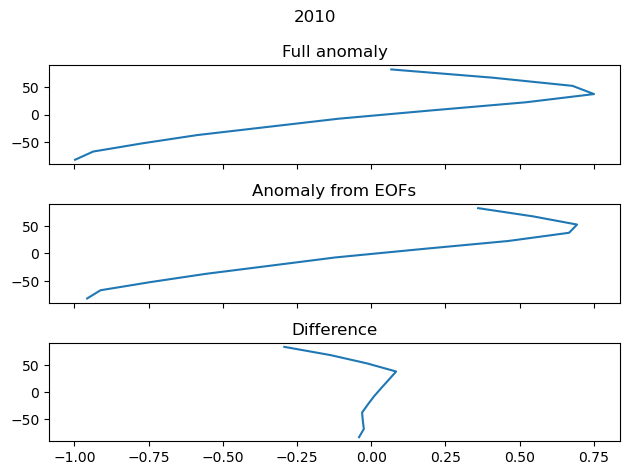

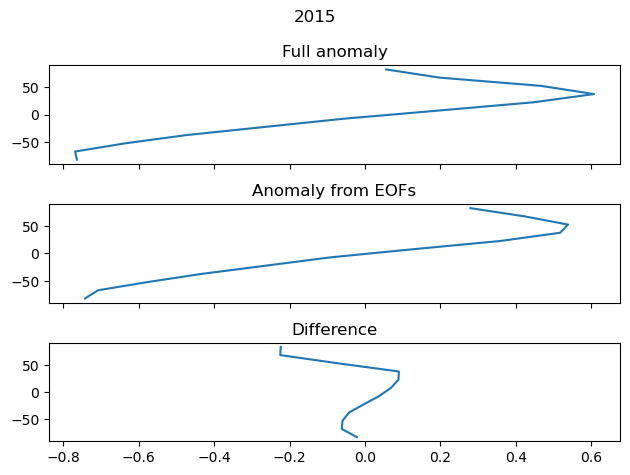

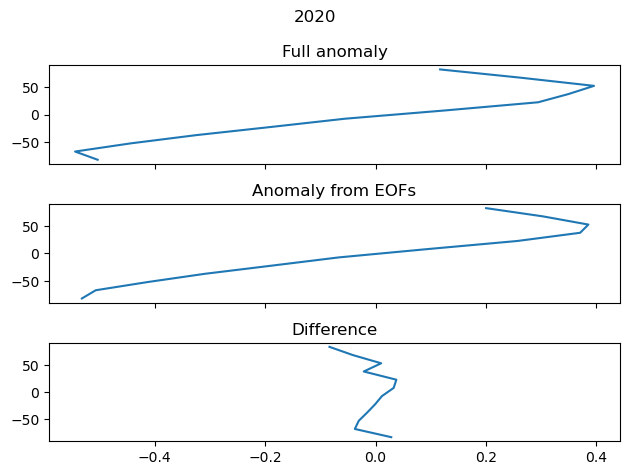

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 16460.87it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19750.41it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19097.85it/s]

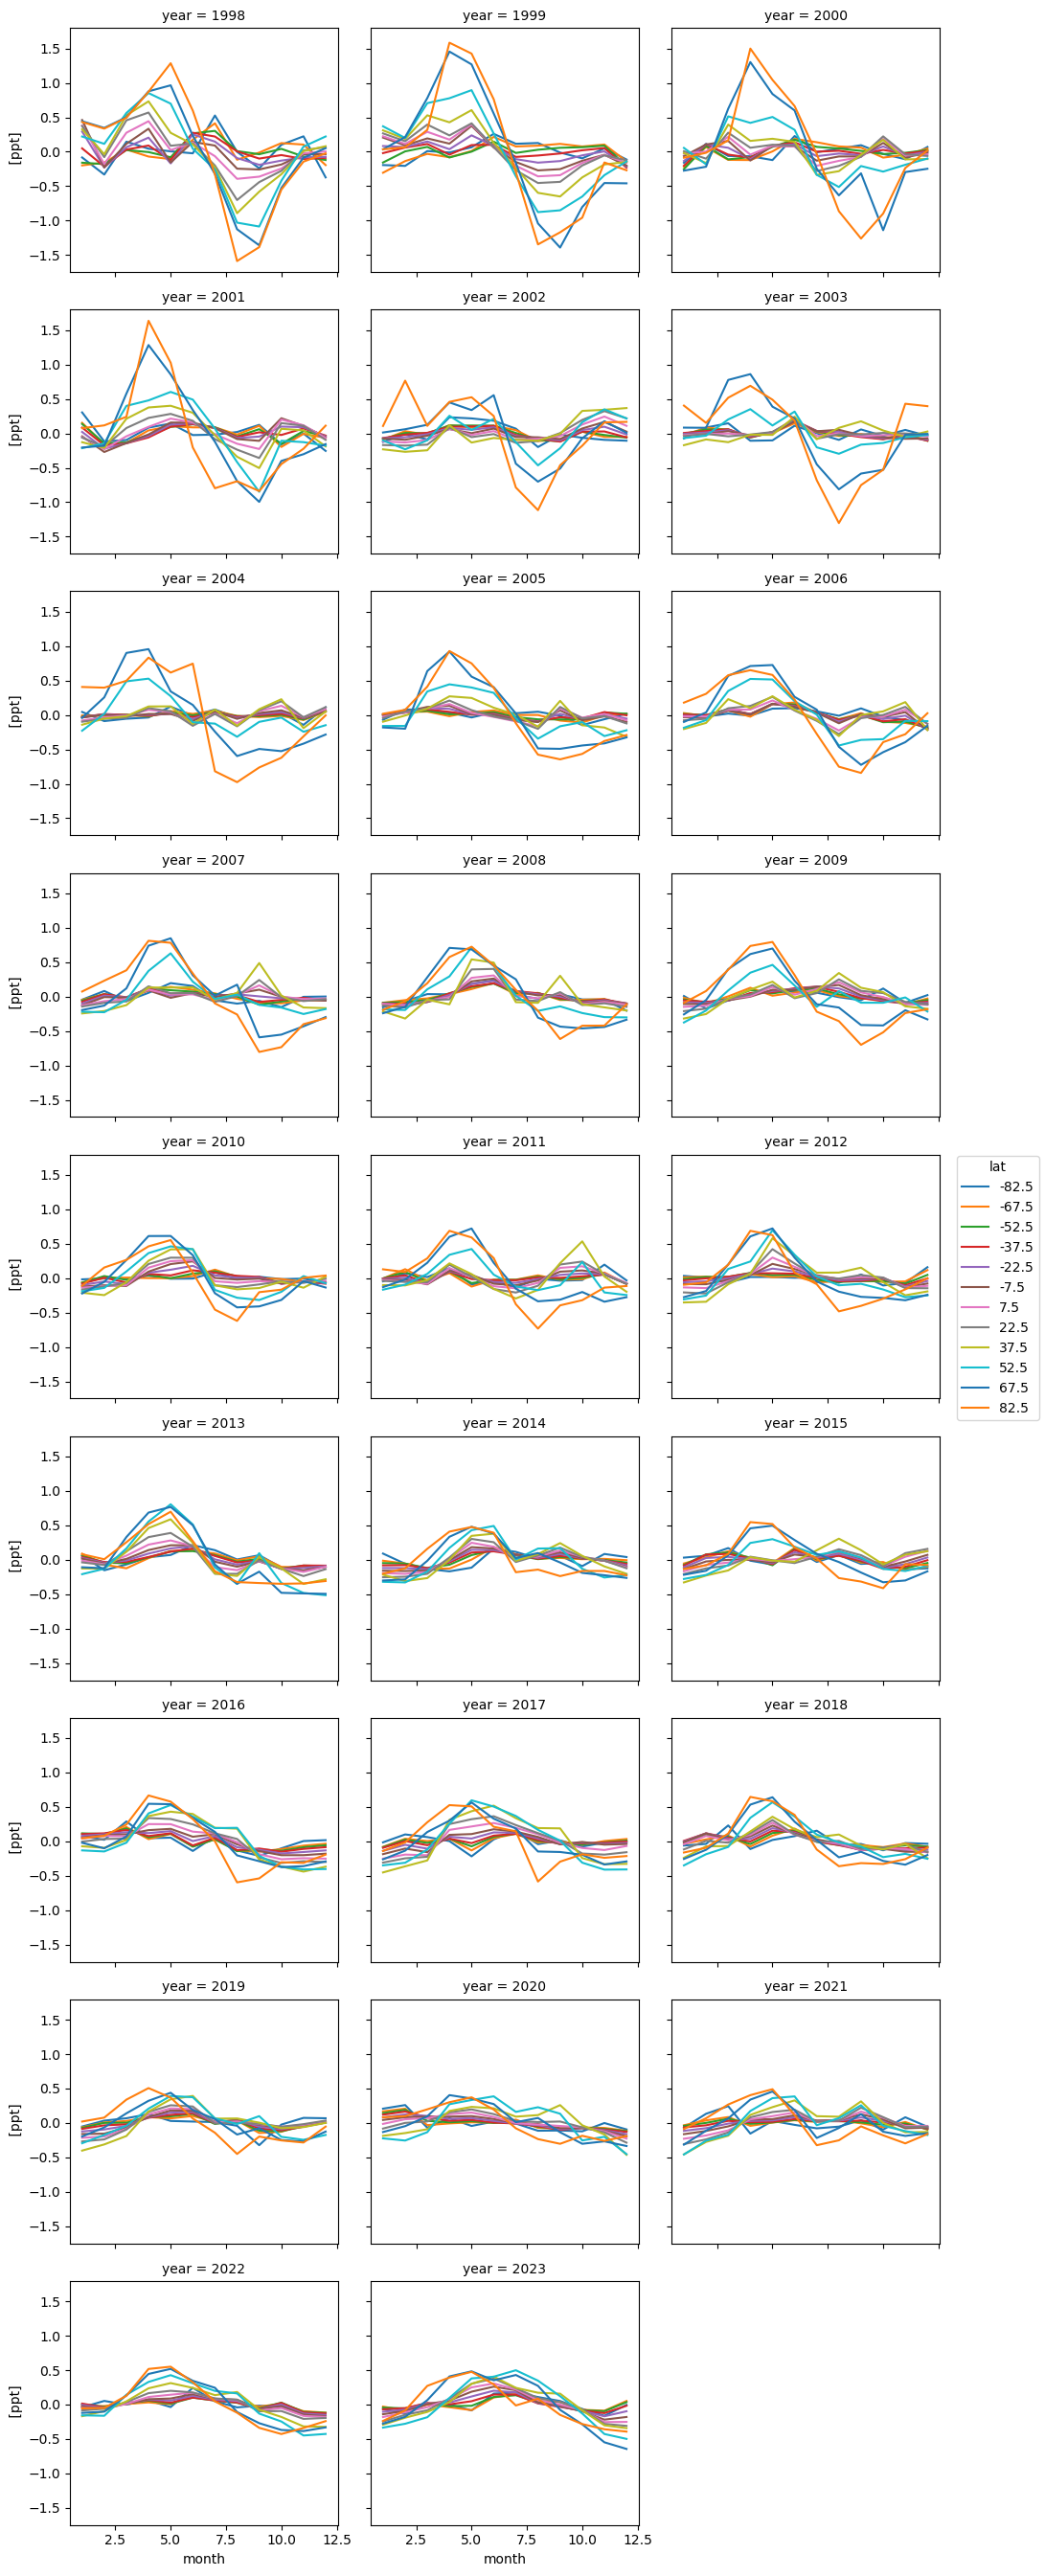

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

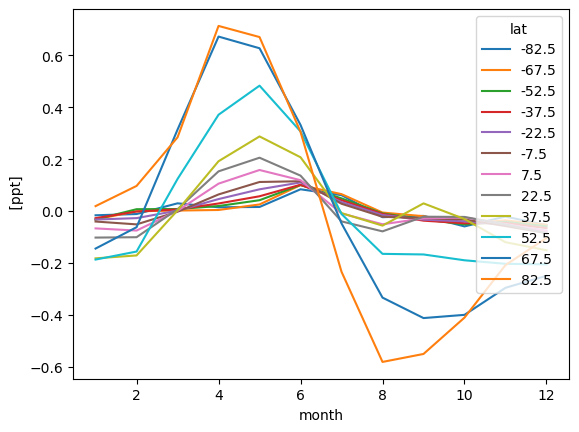

In [22]:
seasonality.plot.line(hue="lat")

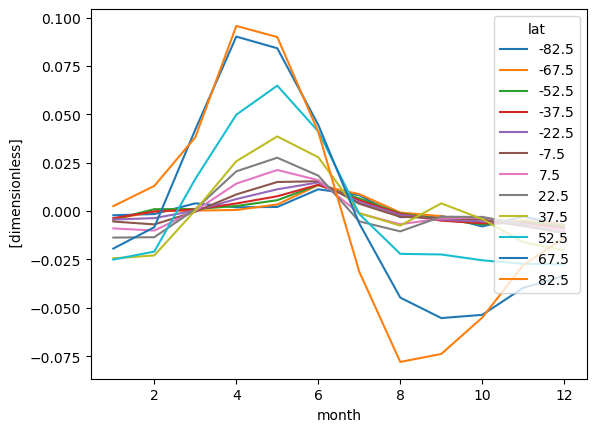

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[9.357660256988835 9.191073882511114 8.9231386176702 8.43978931407696 8.264766037382083 8.18587961647661 7.989521957075778 7.930701588591528 7.755409702845877 7.684927071624169 7.478287006184002 7.3002707291366535 7.226880385636332 7.2237286934377245 7.140142808419597 7.013439920676095 6.8355831573651935 6.77888326888258 6.9468137385999364 6.7290913514709265 6.652764120987006 6.549734925979885 6.625809606876814 6.605350021564892 6.4720150924113655 6.450511427854342]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4597866051964317] [0.4381580270426008] [0.35675784022321416] [0.2675245316882312] [0.1622341362410578] [0.05757096546662261] [-0.07958251948429915] [-0.2219859296677939] [-0.32045766309558177] [-0.33337782147444367] [-0.2620739440945149] [-0.17322294922662262]]
Units,ppt
Magnitude,[[-3.2871812846220743] [-3.3674029386442244] [-3.0621132888866724] [-2.7860954828020894] [-2.5388223051919865] [-2.7459505535401814] [-2.5990922860335437] [-2.5149119373225215] [-2.2610896047478946] [-2.099844632294997] [-2.1213826263673217] [-2.0191123951817893] [-2.081599951408842] [-1.901661965756753] [-1.9086619572773074] [-1.940104377848825] [-1.773600101956477] [-1.613696036689696] [-1.3434920700034936] [-1.374831205341948] [-1.2042707490743194] [-1.429136734927102] [-1.155975455964302] [-1.2225697932263766] [-1.214191428153467] [-1.2726890154552457]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0021846491073172322 -0.001545303453110709 0.003995092118621664 0.0019452562623234948 0.0021169998099490146 0.011248933141185215 0.008215750191840341 -0.003166448549345312 -0.002507119975524822 -0.007938550422976713 -0.0028444400743628463 -0.007335547686809224] [-0.00436344179768888 -0.00010100908620527204 0.00025343100365850523 0.0005555945724268216 0.0034149161480439352 0.013413391945745298 0.008738992916989272 -0.0007705132905191647 -0.0026638205635623547 -0.006575589063708888 -0.004817632226093733 -0.007084329983462318] [-0.004357747293428874 0.0009568356758167384 0.0010521616621348357 0.002596320863996969 0.005604606188811453 0.013466385222911149 0.006540012515691431 -0.0011992004860349411 -0.0042989773009065495 -0.0068934651657546675 -0.005588803418213178 -0.007878135788636562] [-0.003650411217835196 -0.0002434442152880958 0.0008582761248338613 0.003914176543017163 0.007643418599495216 0.013586030271050755 0.00561664776304689 -0.0014757086152384854 -0.004966446551313503 -0.00631244849873739 -0.006134093010486433 -0.008836007366691141] [-0.004391179687357666 -0.003656484157345991 0.0002332087697127937 0.006190507279337568 0.011235118952306777 0.014788783827176724 0.0046209286874316765 -0.0020509788216859074 -0.0044463618870240395 -0.0053384715524401475 -0.007009542670028017 -0.010175545343910014] [-0.005414221319703094 -0.006890723494628135 -0.00035221888838954846 0.008584320688850016 0.015021157064011052 0.015417487090276185 0.003765765174380742 -0.00295057127604519 -0.0037434743406812845 -0.004309348733570049 -0.007755367319294474 -0.011372828137783118] [-0.008965597020471791 -0.010080640647485713 0.00014527175783210573 0.01416435241538822 0.02121861735435886 0.01595042832551854 -0.0012340014348087363 -0.006827774384600494 -0.0038240121781762896 -0.0033189120418022676 -0.006733976750948411 -0.010493784260557344] [-0.013711721144400424 -0.01351768090929213 0.0009447557979211818 0.020517317037974984 0.027564794778612064 0.018305891174461582 -0.0053464086404957836 -0.010498352633460923 -0.0029247566572842536 -0.003037525506803438 -0.0069319207729720295 -0.011364423795627722] [-0.02443859560618877 -0.022942506540130105 0.0003594775098602719 0.025752308277170222 0.03856212623382019 0.027800759210303106 -0.001059599622592832 -0.007532633402218712 0.0039654017945559665 -0.004114114984443664 -0.016092728677374532 -0.020259918524492597] [-0.025075737645793978 -0.0209239315585906 0.016595228608228638 0.04978105707355198 0.06480793673003371 0.04116293553209843 -0.0015380336893883037 -0.02211805278376591 -0.022433334747862282 -0.025444615813011686 -0.027264995632473567 -0.0275484906871433] [-0.019386064180585826 -0.008352059461968436 0.042117846500758234 0.09017204907037318 0.0841380509045046 0.04450329802659924 -0.0063921849729237906 -0.04473552859318143 -0.055307654395495696 -0.053643057132425495 -0.03966031974255488 -0.03345444220849733] [0.002554387371851367 0.012985316670554125 0.03810288817735275 0.09567800605702081 0.08992372509460025 0.040895654998245136 -0.03137980004934123 -0.07797124461561734 -0.0738570237467836 -0.05507177702698024 -0.027920222550005244 -0.01393995828758513]]
Units,dimensionless
